In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cmocean
from sklearn.cluster import KMeans

In [2]:
df_267 = pd.read_csv("bouguer_erg_267.txt",
                     sep=r"\s+",
                     header=None,
                     names=["longitude", "latitude", "bouguer_267"])

df_290 = pd.read_csv("bouguer_erg_290.txt",
                     sep=r"\s+",
                     header=None,
                     names=["longitude", "latitude", "bouguer_290"])

df_topo = pd.read_csv("topo_erg.txt",
                      sep=r"\s+",
                      header=None,
                      names=["longitude", "latitude", "elevation"])

In [3]:
df = pd.DataFrame({
    "longitude"  : df_267["longitude"],
    "latitude"   : df_267["latitude"],
    "bouguer_267": df_267["bouguer_267"],
    "bouguer_290": df_290["bouguer_290"],
    "elevation"  : df_topo["elevation"]
})

df_ocean = df[df["elevation"] < -200].reset_index(drop=True)

In [15]:
wcss = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    kmeans.fit(df_ocean[["longitude", "latitude", "bouguer_267", "bouguer_290"]])
    # inertia_ is the WCSS value
    wcss.append(kmeans.inertia_)

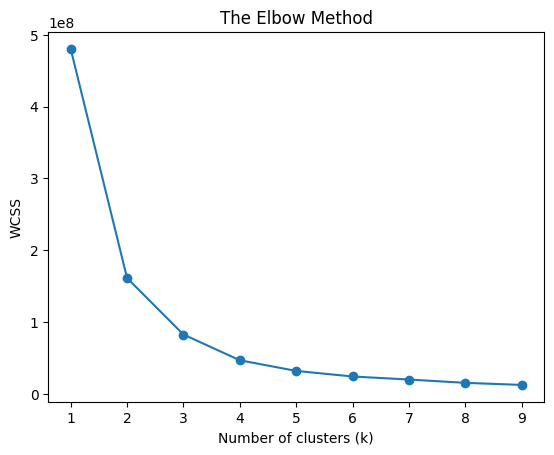

In [16]:
# Plotting the results
plt.plot(k_range, wcss, marker='o')
plt.title('The Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.show()